# 02. STL 기반 대여소 수요 이상 탐지
상위 대여소의 시간대별 수요를 STL로 분해해 구조적 패턴과 실제 이상을 구분합니다.


## 분석 전략

**목표**: 운영적으로 대응 가능한 수요 급증·급감 시점을 찾고, 어떤 유저 그룹이 영향을 받는지 파악한다.

| 단계 | 내용 | 핵심 산출물 |
|---|---|---|
| 1 | 시간대별 대여량 + 유저 클러스터 데이터 로드 | 상위 50개 대여소 선정 |
| 2 | STL 분해로 계절성 제거 → 방법 비교 | STL 선택 근거 |
| 3 | 이상 패턴 분류 (6개 패턴) | 대여소별 이상 시간대 |
| 4 | 클러스터–이상 연계 분석 | 유저 그룹별 피해 대여소 |
| 5 | 운영 해석 및 재배치 우선순위 | 대여소별 대응 규칙 |

**대여소 운영 관점에서 바로 활용 가능한 시계열 이상 탐지**

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_processed
from src.project_helpers import collect_stl_anomalies, setup_korean_matplotlib

setup_korean_matplotlib()
print("✅ 준비 완료")


✅ 준비 완료


## 1. 데이터 로드

분석에는 두 가지 데이터를 사용한다.
- `station_hourly_demand`: 대여소별 시간대 대여량 집계 → STL 이상 탐지에 사용
- `user_clusters`: 01_user_clustering에서 생성한 유저 클러스터 → 대여소별 유저 구성 파악에 사용

📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)
📂 Loaded user_clusters.parquet → shape: (100000, 10)
✅ 전체 시간대 레코드: 3,835,657건
✅ 기간: 2025-10-01 00:00:00 ~ 2025-12-31 23:00:00
✅ 전체 대여소 수: 2,791개
✅ 분석 대상: 상위 50개 대여소
✅ 유저 클러스터 레코드: 100,000건

[상위 10개 대여소 누적 대여량]
stn_id
ST-2031    38539.0
ST-891     26800.0
ST-2045    26155.0
ST-1718    25913.0
ST-413     20670.0
ST-1065    20603.0
ST-3388    18421.0
ST-1681    17700.0
ST-522     16031.0
ST-3311    15373.0


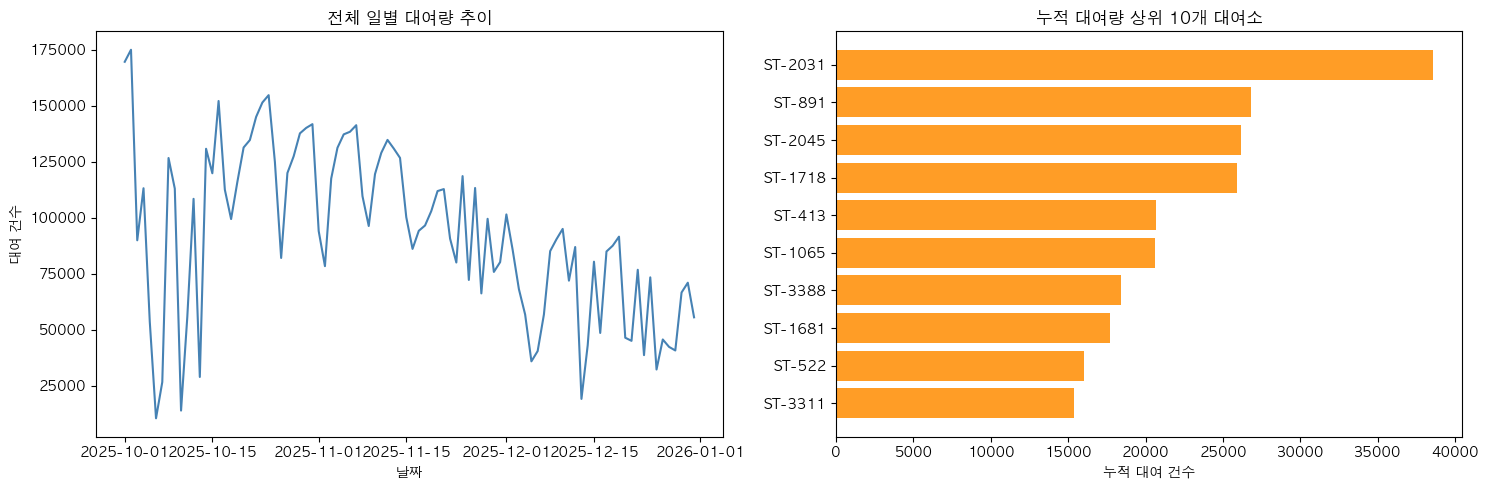

In [2]:
hourly = load_processed("station_hourly_demand").copy()
hourly["datetime_hour"] = pd.to_datetime(hourly["datetime_hour"])

clusters = load_processed("user_clusters").copy()

station_totals = hourly.groupby("stn_id")["rent_count"].sum().sort_values(ascending=False)
top50_stns = station_totals.head(50).index.tolist()
daily_total = hourly.groupby(hourly["datetime_hour"].dt.date)["rent_count"].sum()

print(f"✅ 전체 시간대 레코드: {len(hourly):,}건")
print(f"✅ 기간: {hourly['datetime_hour'].min()} ~ {hourly['datetime_hour'].max()}")
print(f"✅ 전체 대여소 수: {hourly['stn_id'].nunique():,}개")
print(f"✅ 분석 대상: 상위 50개 대여소")
print(f"✅ 유저 클러스터 레코드: {len(clusters):,}건")
print("\n[상위 10개 대여소 누적 대여량]")
print(station_totals.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

daily_total.plot(ax=axes[0], color="steelblue", linewidth=1.5)
axes[0].set_title("전체 일별 대여량 추이")
axes[0].set_xlabel("날짜")
axes[0].set_ylabel("대여 건수")

top10 = station_totals.head(10).sort_values()
axes[1].barh(top10.index.astype(str), top10.values, color="darkorange", alpha=0.85)
axes[1].set_title("누적 대여량 상위 10개 대여소")
axes[1].set_xlabel("누적 대여 건수")

plt.tight_layout()
plt.savefig("../reports/figures/stl_overview.png", dpi=150)
plt.show()

## 2. 방법 비교: STL vs Z-score vs IQR

STL을 선택한 이유를 보이기 위해, 세 방법을 동일한 대여소에 적용해 탐지 결과를 비교합니다.

| 방법 | 계절성 제거 | 한계 |
|---|---|---|
| **Z-score** | ✗ | 반복되는 출근 피크(07~09시)를 이상으로 오탐 |
| **IQR** | ✗ | 동일 문제 |
| **STL** | ✓ | 잔차만 평가 → 반복 패턴은 이상으로 분류되지 않음 |

아래 코드는 대표 대여소 하나를 선택해 각 방법이 어떤 시간대를 이상으로 표시하는지 나란히 보여줍니다.

대표 대여소: ST-2031
  Z-score : 총   54건,  출근(07~09시) 탐지율 10%
  IQR     : 총  142건,  출근(07~09시) 탐지율 20%
  STL     : 총   58건,  출근(07~09시) 탐지율 9%


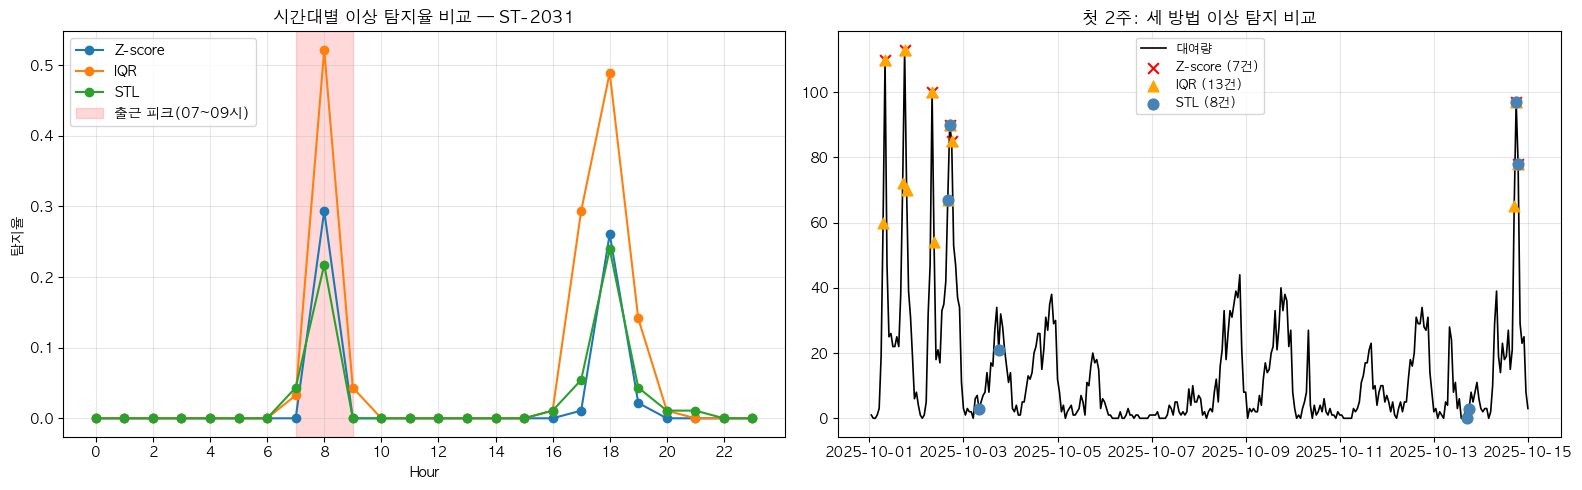


→ Z-score/IQR은 출근 피크를 이상으로 오탐 (계절성 무시)
→ STL은 계절성 제거 후 잔차만 평가하므로 반복 패턴은 잡지 않음


In [3]:
import warnings
from statsmodels.tsa.seasonal import STL as _STL

# 대표 대여소: 누적 대여량 1위
demo_stn = top50_stns[0]
series = (
    hourly.loc[hourly["stn_id"] == demo_stn, ["datetime_hour", "rent_count"]]
    .set_index("datetime_hour")["rent_count"]
    .asfreq("h")
    .fillna(0)
)

# ── Z-score ──────────────────────────────────────────────────────────────────
zscore = (series - series.mean()) / series.std()
anomaly_z = zscore.abs() > 3.0

# ── IQR ──────────────────────────────────────────────────────────────────────
Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
anomaly_iqr = (series < Q1 - 1.5 * (Q3 - Q1)) | (series > Q3 + 1.5 * (Q3 - Q1))

# ── STL ──────────────────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    stl_result = _STL(series, period=24, robust=True).fit()
resid_std = stl_result.resid.std()
anomaly_stl = stl_result.resid.abs() > 3.0 * resid_std

# ── 시간대별 탐지율 비교 ────────────────────────────────────────────────────
df_hourly_cmp = pd.DataFrame({
    "Z-score": anomaly_z,
    "IQR":     anomaly_iqr,
    "STL":     anomaly_stl,
})
df_hourly_cmp["hour"] = series.index.hour
fp_by_hour = df_hourly_cmp.groupby("hour")[["Z-score", "IQR", "STL"]].mean()

print(f"대표 대여소: {demo_stn}")
for method, mask in [("Z-score", anomaly_z), ("IQR", anomaly_iqr), ("STL", anomaly_stl)]:
    morning_rate = mask[series.index.hour.isin([7, 8, 9])].mean()
    print(f"  {method:8s}: 총 {mask.sum():4d}건,  출근(07~09시) 탐지율 {morning_rate:.0%}")

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 시간대별 탐지율
fp_by_hour.plot(ax=axes[0], marker="o", linewidth=1.5)
axes[0].axvspan(7, 9, alpha=0.15, color="red", label="출근 피크(07~09시)")
axes[0].set_title(f"시간대별 이상 탐지율 비교 — {demo_stn}")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("탐지율")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# 오른쪽: 첫 2주 시계열 + 각 방법 이상 표시
window = series.iloc[:336]
axes[1].plot(window.index, window.values, color="black", lw=1.2, label="대여량", zorder=3)
for method, mask, color, marker in [
    ("Z-score", anomaly_z, "red",      "x"),
    ("IQR",     anomaly_iqr, "orange", "^"),
    ("STL",     anomaly_stl, "steelblue", "o"),
]:
    m = mask.iloc[:336]
    axes[1].scatter(
        window.index[m], window.values[m],
        color=color, marker=marker, s=60, zorder=5,
        label=f"{method} ({m.sum()}건)"
    )
axes[1].set_title("첫 2주: 세 방법 이상 탐지 비교")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/anomaly_method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ Z-score/IQR은 출근 피크를 이상으로 오탐 (계절성 무시)")
print("→ STL은 계절성 제거 후 잔차만 평가하므로 반복 패턴은 잡지 않음")

### STL 선택 이유 요약

```
원본 = 추세(Trend) + 계절성(Seasonal, period=24) + 잔차(Residual)
```

계절성이 분리된 **잔차**에만 3σ를 적용하므로, 매일 반복되는 출근 피크는
계절성 성분으로 흡수되어 잔차가 작습니다.
진짜 이상은 **패턴을 초과하는 잔차**에서만 감지됩니다.

## 3. STL 기반 수요 이상 탐지

각 대여소의 시간대별 대여량 시계열에 `STL(period=24, robust=True)`을 적용해 하루 주기의 계절성을 분리한다. 이후 잔차의 절댓값이 `3σ`를 넘는 시점을 이상으로 정의하고, 이를 운영적으로 해석 가능한 패턴으로 분류한다.

패턴 분류 기준은 다음과 같다.

| 패턴 | 조건 | 운영 의미 |
|---|---|---|
| `공휴일` | 법정 공휴일 발생 | 구조적 수요 변화 |
| `주말` | 주말 발생 | 구조적 수요 차이 |
| `평일 출근 급감` | 평일 08시 + 음의 잔차 | 오전형 유저 이용 불가 → 야간 재배치 필요 |
| `평일 출근 급증` | 평일 08시 + 양의 잔차 | 반납 집중으로 거치대 포화 가능성 |
| `평일 저녁 급증` | 평일 17~19시 + 양의 잔차 | 저녁형 유저 수요 폭발 → 17시 전 재배치 필요 |
| `평일 저녁 급감` | 평일 17~19시 + 음의 잔차 | 퇴근 시간 자전거 고갈 → 즉시 대응 필요 |
| `기타 급증/급감` | 그 외 | 원인 불명, 사후 분석 필요 |

분석 스테이션: 50개
전체 STL 이상 시간대: 2,776개

=== 패턴별 분류 ===
pattern
주말          1275
평일 저녁 급증     499
기타 급증        348
기타 급감        177
평일 출근 급증     174
평일 저녁 급감     167
공휴일          116
평일 출근 급감      20

=== 이상 집중 날짜 Top 10 ===
date
2025-10-08    154
2025-10-16    113
2025-10-25    105
2025-11-01     97
2025-11-09     96
2025-10-10     93
2025-10-14     90
2025-11-02     87
2025-10-13     83
2025-10-19     81


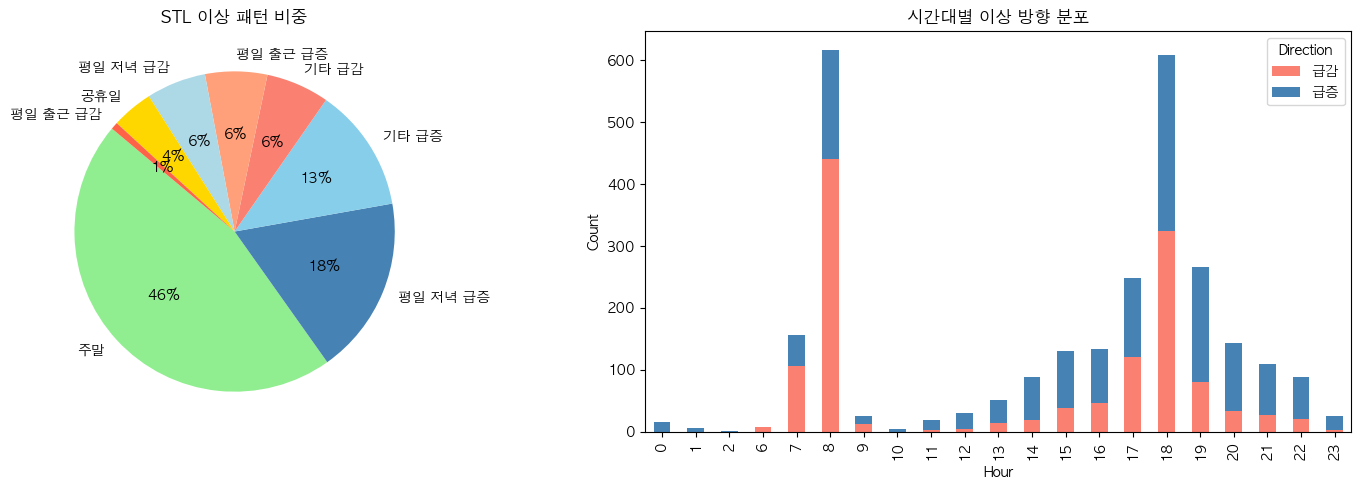

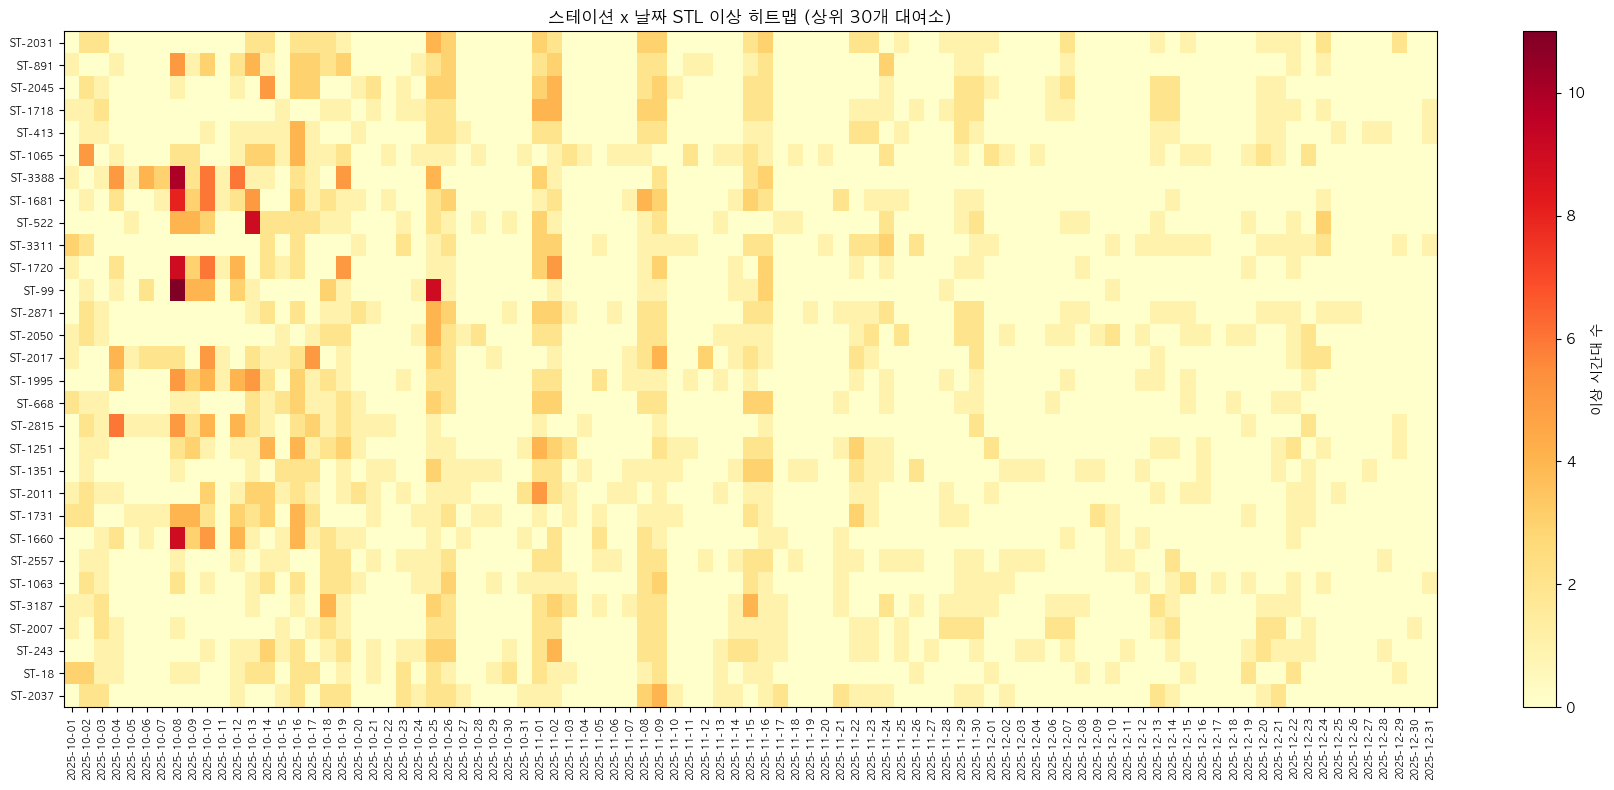

In [4]:
stl_all = collect_stl_anomalies(hourly, top50_stns)

pattern_counts = stl_all["pattern"].value_counts()
hour_dir = stl_all.groupby("hour")["direction"].value_counts().unstack(fill_value=0)
top_dates = stl_all["date"].value_counts().head(10)

print(f"분석 스테이션: {len(top50_stns)}개")
print(f"전체 STL 이상 시간대: {len(stl_all):,}개")
print("\n=== 패턴별 분류 ===")
print(pattern_counts.to_string())
print("\n=== 이상 집중 날짜 Top 10 ===")
print(top_dates.to_string())

palette = {
    "공휴일":       "gold",
    "주말":         "lightgreen",
    "평일 출근 급감": "tomato",
    "평일 출근 급증": "lightsalmon",
    "평일 저녁 급증": "steelblue",
    "평일 저녁 급감": "lightblue",
    "기타 급감":     "salmon",
    "기타 급증":     "skyblue",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_pie = [palette.get(name, "gray") for name in pattern_counts.index]
axes[0].pie(pattern_counts.values, labels=pattern_counts.index, autopct="%1.0f%%", colors=colors_pie, startangle=140)
axes[0].set_title("STL 이상 패턴 비중")

hour_dir.plot(kind="bar", stacked=True, ax=axes[1], color=["salmon", "steelblue"])
axes[1].set_title("시간대별 이상 방향 분포")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")
axes[1].legend(title="Direction")

plt.tight_layout()
plt.savefig("../reports/figures/stl_pattern_calendar.png", dpi=150)
plt.show()

pivot = stl_all.groupby(["stn_id", "date"]).size().unstack(fill_value=0)
pivot_plot = pivot.reindex(station_totals.head(30).index).fillna(0)

fig, ax = plt.subplots(figsize=(18, 8))
im = ax.imshow(pivot_plot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(len(pivot_plot)))
ax.set_yticklabels(pivot_plot.index.astype(str), fontsize=7)
ax.set_xticks(range(len(pivot_plot.columns)))
ax.set_xticklabels([str(d) for d in pivot_plot.columns], rotation=90, fontsize=7)
ax.set_title("스테이션 x 날짜 STL 이상 히트맵 (상위 30개 대여소)")
plt.colorbar(im, ax=ax, label="이상 시간대 수")
plt.tight_layout()
plt.savefig("../reports/figures/stl_station_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

```markdown
실질적인 운영 대응 대상은 **평일 저녁(17~19시) 관련 이상 24%**다.
저녁 시간대 이상의 실제 규모가 더 컸음을 확인했다.

시간대별 방향 분포에서 주목할 점은 **18시의 이중성**이다.
- 일부 대여소: 수요 폭발로 자전거 고갈 (급증)
- 다른 대여소: 반납 집중으로 거치대 포화 (급감)

동일한 18시라도 대여소마다 문제 방향이 반대이므로,
일괄 재배치보다 **대여소별 개별 대응 규칙**이 필요하다.
이는 다음 섹션의 클러스터–이상 연계 분석으로 이어진다.
```

## 4. 문제 대여소 식별

전체 이상 중 운영 대응이 필요한 패턴(평일 출근·저녁 급증·급감)이 반복적으로 발생하는 대여소를 찾는다.
반복성이 높을수록 사전 재배치 규칙을 적용했을 때 효과가 크다.

=== 운영 이상 빈도 상위 15개 대여소 ===
pattern  평일 출근 급감  평일 출근 급증  평일 저녁 급증  평일 저녁 급감  합계
stn_id                                             
ST-3094         1         6        16         8  31
ST-1064         0         1        25         3  29
ST-18           0         0        25         3  28
ST-3311         0         2        21         3  26
ST-1263         2        10        13         0  25
ST-1351         1        20         2         1  24
ST-513          0         6        13         5  24
ST-1065         0         6        12         5  23
ST-1251         1         9        11         2  23
ST-522          0         2        15         5  22
ST-1063         0         3        17         2  22
ST-1709         0         1        17         3  21
ST-243          3         9         8         1  21
ST-2871         0         3        16         1  20
ST-1681         0         0        11         9  20


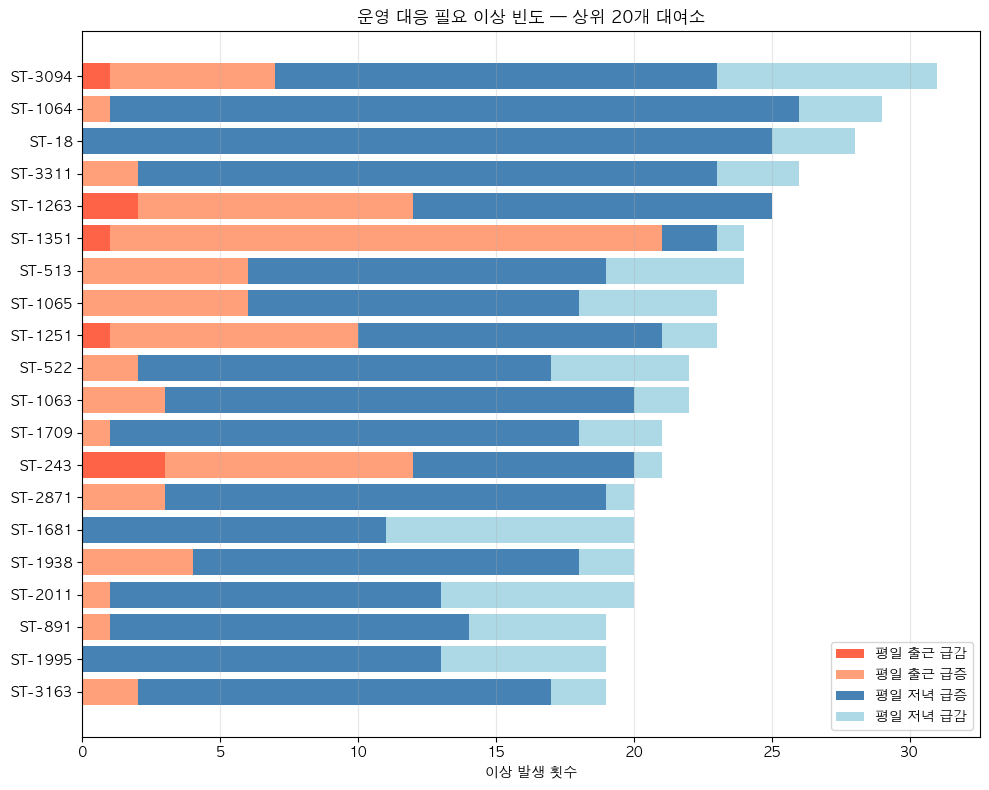

In [10]:
# ── 운영 대응 필요 패턴만 필터 ───────────────────────────────────────────────
action_patterns = ["평일 출근 급감", "평일 출근 급증", "평일 저녁 급증", "평일 저녁 급감"]
stl_action = stl_all[stl_all["pattern"].isin(action_patterns)].copy()

# ── 대여소 × 패턴별 이상 횟수 집계 ──────────────────────────────────────────
stn_pattern = (
    stl_action.groupby(["stn_id", "pattern"])
    .size()
    .unstack(fill_value=0)
)
# 누락 컬럼 보완
for col in action_patterns:
    if col not in stn_pattern.columns:
        stn_pattern[col] = 0
stn_pattern = stn_pattern[action_patterns]
stn_pattern["합계"] = stn_pattern.sum(axis=1)
stn_pattern = stn_pattern.sort_values("합계", ascending=False)

print("=== 운영 이상 빈도 상위 15개 대여소 ===")
print(stn_pattern.head(15).to_string())

# ── 시각화: 상위 20개 대여소 누적 막대 ───────────────────────────────────────
top20 = stn_pattern.head(20).drop(columns="합계").iloc[::-1]

palette_action = {
    "평일 출근 급감": "tomato",
    "평일 출근 급증": "lightsalmon",
    "평일 저녁 급증": "steelblue",
    "평일 저녁 급감": "lightblue",
}

fig, ax = plt.subplots(figsize=(10, 8))
left = pd.Series(0, index=top20.index)
for pattern in action_patterns:
    if pattern in top20.columns:
        ax.barh(top20.index.astype(str), top20[pattern], left=left,
                color=palette_action[pattern], label=pattern)
        left += top20[pattern]

ax.set_xlabel("이상 발생 횟수")
ax.set_title("운영 대응 필요 이상 빈도 — 상위 20개 대여소")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/station_action_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 운영 해석

### 패턴별 대응 전략

| 패턴 | 비중 | 대응 |
|---|---|---|
| 주말 | ~46% | 구조적 수요 차이 — 별도 대응 불필요 |
| 기타 급증/급감 | ~31% | 사후 원인 분석 |
| **평일 저녁 급증** | ~18% | **17시 전 자전거 사전 배치** |
| 평일 출근 급감 | ~1% | 야간 재배치로 해소 |
| 평일 출근 급증 | 신규 | 거치대 포화 모니터링 |
| 평일 저녁 급감 | 신규 | 퇴근 시간 즉시 대응 |

### 클러스터 맥락

- **평일 출근 이상** → 전체 유저의 **35%인 오전형**이 직접 피해를 받는 상황. 야간에 자전거를 미리 배치해두면 해소 가능.
- **평일 저녁 급증/급감** → 전체 유저의 **51%인 저녁형**이 몰리는 상황. 규모가 가장 크고 반복성이 높아 운영 우선순위 1순위.
- **주말 이상** → 13%인 장거리·여가형 유저의 패턴 차이. 예측 가능한 구조적 변화로 별도 대응보다 주말 전용 배치 기준 수립이 효과적.

### 재배치 규칙 요약

섹션 4의 우선순위 점수를 기반으로 두 가지 운영 규칙을 설계한다.

1. **야간 재배치 대상**: 오전형 비율 高 + 출근 이상 多인 대여소 → 전날 22~24시 자전거 집중 배치
2. **17시 전 재배치 대상**: 저녁형 비율 高 + 저녁 이상 多인 대여소 → 당일 16~17시 자전거 사전 이동